# Assignment 14: Breast Cancer Classification with Logistic Regression

In [7]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.exceptions import UndefinedMetricWarning


def load_data():
    data = load_breast_cancer(as_frame=True)
    class_names = list(data.target_names)
    return data.data, data.target, class_names


def split_and_scale(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


def train_model(X_train, y_train, max_iter=5000):
    model = LogisticRegression(max_iter=max_iter)
    model.fit(X_train, y_train)
    return model


def get_confusion_matrix(y_true, y_pred, labels):
    return confusion_matrix(y_true, y_pred, labels=labels)


def get_classification_report(y_true, y_pred, target_names):
    return classification_report(y_true, y_pred, target_names=target_names, output_dict=True)


def get_roc_auc(y_true, y_score, pos_label):
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=pos_label)
    auc_value = auc(fpr, tpr)
    return fpr, tpr, auc_value

In [8]:
# sample answer: load, split with no leakage, scale using train statistics only
X, y, class_names = load_data()
malignant_label = class_names.index("malignant")
X_train, X_test, y_train, y_test, scaler = split_and_scale(X, y)
model = train_model(X_train, y_train)
y_pred = model.predict(X_test)
y_proba_malignant = model.predict_proba(X_test)[:, malignant_label]
print(class_names, "malignant label:", malignant_label)
print(X_train.shape, X_test.shape)

[np.str_('malignant'), np.str_('benign')] malignant label: 0
(455, 30) (114, 30)


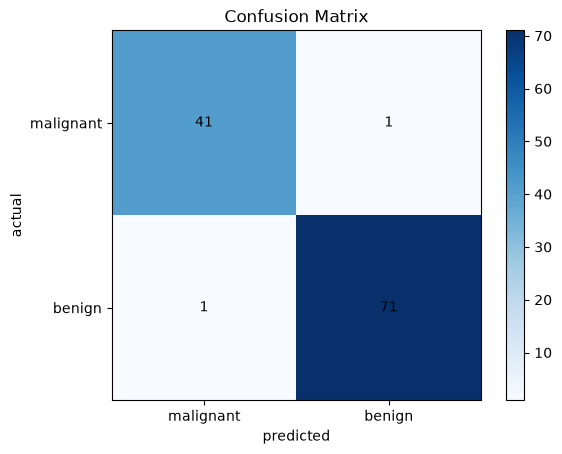

[[41  1]
 [ 1 71]]


In [9]:
# confusion matrix
labels = [malignant_label, 1 - malignant_label]
cm = get_confusion_matrix(y_test, y_pred, labels=labels)
cm_names = [class_names[labels[0]], class_names[labels[1]]]

fig1, ax1 = plt.subplots()
im = ax1.imshow(cm, cmap="Blues")
ax1.set_xticks([0, 1])
ax1.set_yticks([0, 1])
ax1.set_xticklabels(cm_names)
ax1.set_yticklabels(cm_names)
ax1.set_xlabel("predicted")
ax1.set_ylabel("actual")
ax1.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax1.text(j, i, cm[i, j], ha="center", va="center")
fig1.colorbar(im)
plt.show()
print(cm)

In [10]:
# classification report, with a focus on the malignant class
report = get_classification_report(y_test, y_pred, target_names=class_names)
malignant_metrics = report["malignant"]
print(pd.DataFrame(report).T)
print("malignant precision:", malignant_metrics["precision"])
print("malignant recall:", malignant_metrics["recall"])
print("malignant f1-score:", malignant_metrics["f1-score"])

              precision    recall  f1-score     support
malignant      0.976190  0.976190  0.976190   42.000000
benign         0.986111  0.986111  0.986111   72.000000
accuracy       0.982456  0.982456  0.982456    0.982456
macro avg      0.981151  0.981151  0.981151  114.000000
weighted avg   0.982456  0.982456  0.982456  114.000000
malignant precision: 0.9761904761904762
malignant recall: 0.9761904761904762
malignant f1-score: 0.9761904761904762


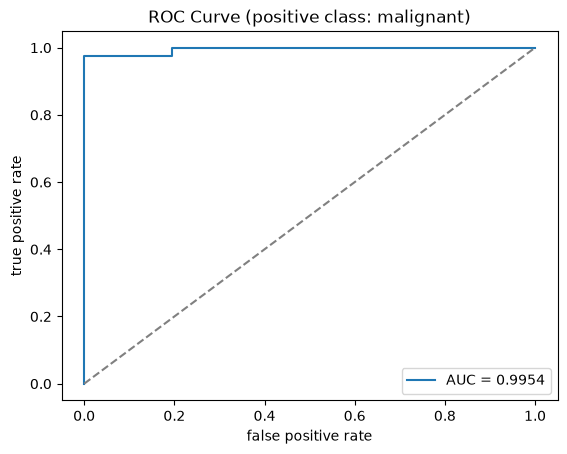

auc: 0.9953703703703705


In [11]:
# roc curve and auc, using malignant as the positive class
fpr, tpr, auc_value = get_roc_auc(y_test, y_proba_malignant, pos_label=malignant_label)

fig2, ax2 = plt.subplots()
ax2.plot(fpr, tpr, label=f"AUC = {auc_value:.4f}")
ax2.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax2.set_xlabel("false positive rate")
ax2.set_ylabel("true positive rate")
ax2.set_title("ROC Curve (positive class: malignant)")
ax2.legend()
plt.show()
print("auc:", auc_value)

In [12]:
# edge and negative case checks, kept separate from the analysis above

# confusion matrix on a hand computed example
cm_true = [0, 0, 1, 1, 0]
cm_pred = [0, 1, 1, 1, 0]
cm_result = get_confusion_matrix(cm_true, cm_pred, labels=[0, 1])
assert np.array_equal(cm_result, [[2, 1], [0, 2]])

perfect = get_confusion_matrix([0, 1, 1, 0], [0, 1, 1, 0], labels=[0, 1])
assert perfect[0, 1] == 0 and perfect[1, 0] == 0

try:
    get_confusion_matrix([0, 1], [0, 1, 1], labels=[0, 1])
    assert False, "expected ValueError for mismatched lengths"
except ValueError:
    pass

# classification report on a hand computed example
report_true = [0, 0, 0, 1, 1, 1, 1, 1]
report_pred = [0, 0, 1, 1, 1, 0, 1, 1]
synth_report = get_classification_report(report_true, report_pred, target_names=["class0", "class1"])
assert abs(synth_report["class1"]["precision"] - 0.8) < 1e-9
assert abs(synth_report["class1"]["recall"] - 0.8) < 1e-9
assert abs(synth_report["class1"]["f1-score"] - 0.8) < 1e-9

try:
    get_classification_report(report_true, report_pred, target_names=["class0", "class1", "class2"])
    assert False, "expected ValueError for a target_names length mismatch"
except ValueError:
    pass

try:
    get_classification_report([], [], target_names=["class0", "class1"])
    assert False, "expected ValueError for empty inputs"
except ValueError:
    pass

# roc and auc on hand computed examples
perfect_fpr, perfect_tpr, perfect_auc = get_roc_auc([0, 0, 1, 1], [0.1, 0.2, 0.8, 0.9], pos_label=1)
assert abs(perfect_auc - 1.0) < 1e-9

tied_fpr, tied_tpr, tied_auc = get_roc_auc([0, 1, 0, 1], [0.5, 0.5, 0.5, 0.5], pos_label=1)
assert abs(tied_auc - 0.5) < 1e-9

with warnings.catch_warnings():
    warnings.simplefilter("ignore", UndefinedMetricWarning)
    single_class_fpr, single_class_tpr, single_class_auc = get_roc_auc([0, 0, 0, 0], [0.1, 0.4, 0.3, 0.9], pos_label=1)
assert np.isnan(single_class_auc)

# leakage check: the scaler must be fit on the training split only
X_train_raw, X_test_raw, _, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
assert np.allclose(scaler.mean_, X_train_raw.mean(axis=0).to_numpy())
assert not np.allclose(scaler.mean_, X.mean(axis=0).to_numpy())

try:
    split_and_scale(X, y, test_size=1.5)
    assert False, "expected ValueError for an invalid test_size"
except ValueError:
    pass

train_a, _, ytr_a, _, _ = split_and_scale(X, y)
train_b, _, ytr_b, _, _ = split_and_scale(X, y)
assert np.allclose(train_a, train_b)
assert ytr_a.equals(ytr_b)

try:
    train_model(np.empty((0, 5)), np.empty((0,)))
    assert False, "expected ValueError for empty training data"
except ValueError:
    pass

print("all tests passed")

all tests passed
